**Part1**  

Data processing pipeline

In [19]:
# We load the dataset and import the librabries that we need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

URL = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(URL)
print(df.shape)
print(df.dtypes)

(1000, 16)
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [20]:
# We check how the entities look and how the columns are strctured what inconsistencies they might have

print(df.head(2))

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   

               Series_Title Released_Year Certificate  Runtime         Genre  \
0  The Shawshank Redemption          1994           A  142 min         Drama   
1             The Godfather          1972           A  175 min  Crime, Drama   

   IMDB_Rating                                           Overview  Meta_score  \
0          9.3  Two imprisoned men bond over a number of years...        80.0   
1          9.2  An organized crime dynasty's aging patriarch t...       100.0   

               Director          Star1           Star2       Star3  \
0        Frank Darabont    Tim Robbins  Morgan Freeman  Bob Gunton   
1  Francis Ford Coppola  Marlon Brando       Al Pacino  James Caan   

            Star4  No_of_Votes        Gross  
0  William Sadler      2343110   28,341,469  
1    Diane Keaton      1620367  134,966,411

Data Cleaning

In [21]:
# Here we clean the numerical columns, drop duplicates and print the result

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean['Runtime'] = pd.to_numeric(
    df_clean['Runtime'].str.replace(' min', '', regex=False), errors='coerce')
df_clean['Gross'] = pd.to_numeric(
    df_clean['Gross'].str.replace(',', '', regex=False), errors='coerce')
df_clean['Released_Year'] = pd.to_numeric(
    df_clean['Released_Year'], errors='coerce')

df_clean = df_clean.dropna(subset=['Released_Year'])
df_clean['Released_Year'] = df_clean['Released_Year'].astype(int)

print(df_clean[['Runtime', 'Gross', 'Released_Year']].dtypes)
print(df_clean[['Runtime', 'Gross', 'Released_Year']].head())
df_clean.shape

Runtime            int64
Gross            float64
Released_Year      int64
dtype: object
   Runtime        Gross  Released_Year
0      142   28341469.0           1994
1      175  134966411.0           1972
2      152  534858444.0           2008
3      202   57300000.0           1974
4       96    4360000.0           1957


(999, 16)

In [22]:
# We check which columns have missing values

missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
Certificate    101
Meta_score     157
Gross          169
dtype: int64


In [23]:
# Here we will use 2 separate strategies for handling missing data
# one used for numerical data(we use median)
# the other one for categorical data(We fill with unknown)
# another strategy would be to simply remove the rows that have incomplete
# data but as it is we only have 1000 elements so that would not be best
# Also it would be to fill for categorical data with the the mode, but I believe its better with unknown

df_clean['Certificate'] = df_clean['Certificate'].fillna('Unknown')

for col in ['Meta_score', 'Gross']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print(f"Total remaining NaNs: {df_clean.isnull().sum().sum()}")

Total remaining NaNs: 0


In [24]:
# Here we visualize the numer of possible outliers for the numerical columns

numerical_cols = ['IMDB_Rating', 'Meta_score', 'Runtime', 'Gross', 'No_of_Votes']

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f"{col}: {n} outliers, bounds [{lower}, {upper}], min={df_clean[col].min()},  max={df_clean[col].max()}")

IMDB_Rating: 13 outliers, bounds [7.100000000000001, 8.7], min=7.6,  max=9.3
Meta_score: 25 outliers, bounds [51.75, 105.75], min=28.0,  max=100.0
Runtime: 29 outliers, bounds [52.0, 188.0], min=45,  max=321
Gross: 124 outliers, bounds [-79555471.25, 145957354.75], min=1305.0,  max=936662225.0
No_of_Votes: 67 outliers, bounds [-423037.5, 852986.5], min=25088,  max=2343110


Even though we have outliers they belong to real movies meaning real data , so the removal of these would not make sense

In [25]:
# Here we check the categorical columns by seeing what and how many unique values
# each of them has .
categorical_cols = ['Certificate', 'Genre', 'Director',
                    'Star1', 'Star2', 'Star3', 'Star4']

for col in categorical_cols :
    print(f"{df_clean[col].value_counts()}\n")



Certificate
U           233
A           197
UA          175
R           146
Unknown     101
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
Unrated       1
TV-MA         1
16            1
U/A           1
Name: count, dtype: int64

Genre
Drama                        85
Drama, Romance               37
Comedy, Drama                35
Comedy, Drama, Romance       31
Action, Crime, Drama         30
                             ..
Action, Adventure, Family     1
Action, Crime, Mystery        1
Animation, Drama, Romance     1
Drama, War, Western           1
Adventure, Comedy, War        1
Name: count, Length: 202, dtype: int64

Director
Alfred Hitchcock    14
Steven Spielberg    13
Hayao Miyazaki      11
Akira Kurosawa      10
Martin Scorsese     10
                    ..
Kinji Fukasaku       1
Eric Bress           1
Thomas Kail          1
Irvin Kershner       1
Lana Wachowski       1
Name: count, Length: 548, dty

In [26]:
# We will fix the certifcate from 15 + unique values to just 4 

certificate_mapping = {
    'U':        'Universal',
    'G':        'Universal',
    'PG':       'Universal',
    'GP':       'Universal',    
    'TV-PG':    'Universal',    
    'Passed':   'Universal',    
    'Approved': 'Universal',    

    'UA':       'UnderSupervision',
    'U/A':      'UnderSupervision',  
    'PG-13':    'UnderSupervision',
    'TV-14':    'UnderSupervision',

    
    'A':        'Adult',
    'R':        'Adult',
    'TV-MA':    'Adult',
    'Unrated':  'Adult',       
    '16':       'Adult',
    
    'Unknown':  'Unknown',
}

df_clean['Certificate'] = (
    df_clean['Certificate']
    .map(certificate_mapping)
    .fillna('Unknown')
)

df_clean['Certificate'].value_counts()

Certificate
Adult               346
Universal           332
UnderSupervision    220
Unknown             101
Name: count, dtype: int64

In [27]:
# We make out of Genre -> Genre_List so it is easier for one shot encoding later 
df_clean['Genre_List'] = (df_clean['Genre']
    .str.split(',')
    .apply(lambda x: [g.strip() for g in x]))
print(df_clean['Genre_List'].head())


0                   [Drama]
1            [Crime, Drama]
2    [Action, Crime, Drama]
3            [Crime, Drama]
4            [Crime, Drama]
Name: Genre_List, dtype: object


Data transformation

In [28]:
# We want to get a good understanding of the columns before data transformation
# To see what type of algorithm we use for each transformation(numerical, categorical)

print("Columns before transformation:")
print(df_clean.dtypes)
print(f"Shape: {df_clean.shape}")

Columns before transformation:
Poster_Link       object
Series_Title      object
Released_Year      int64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
Genre_List        object
dtype: object
Shape: (999, 17)


In [29]:
# We will use one-hot encoding for genre and certificate
# Difference is that while a movie can have one type of certificate
# It can have multiple types of genres

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df_clean['Genre_List']),
    columns=[f'Genre_{g}' for g in mlb.classes_],
    index=df_clean.index
)

cert_encoded = pd.get_dummies(df_clean['Certificate'], prefix='Cert')

df_clean = pd.concat([df_clean, genre_encoded, cert_encoded], axis=1)

print("Genre columns added:")
print(genre_encoded.columns.tolist())
print(f"\nCertificate columns added:")
print(cert_encoded.columns.tolist())
print(f"\nShape after encoding: {df_clean.shape}")

Genre columns added:
['Genre_Action', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy', 'Genre_Film-Noir', 'Genre_History', 'Genre_Horror', 'Genre_Music', 'Genre_Musical', 'Genre_Mystery', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Sport', 'Genre_Thriller', 'Genre_War', 'Genre_Western']

Certificate columns added:
['Cert_Adult', 'Cert_UnderSupervision', 'Cert_Universal', 'Cert_Unknown']

Shape after encoding: (999, 42)


In [30]:
# We will use standardization for the numerical columns so we can use pca later

numerical_cols = ['IMDB_Rating', 'Meta_score', 'Runtime', 'Gross', 'No_of_Votes', 'Released_Year']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[numerical_cols])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f'{col}_Scaled' for col in numerical_cols],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, scaled_df], axis=1)

print("Scaled columns added:")
print(scaled_df.info())
print(f"\nShape after scaling: {df_clean.shape}")


Scaled columns added:
<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IMDB_Rating_Scaled    999 non-null    float64
 1   Meta_score_Scaled     999 non-null    float64
 2   Runtime_Scaled        999 non-null    float64
 3   Gross_Scaled          999 non-null    float64
 4   No_of_Votes_Scaled    999 non-null    float64
 5   Released_Year_Scaled  999 non-null    float64
dtypes: float64(6)
memory usage: 54.6 KB
None

Shape after scaling: (999, 48)


Data reduction

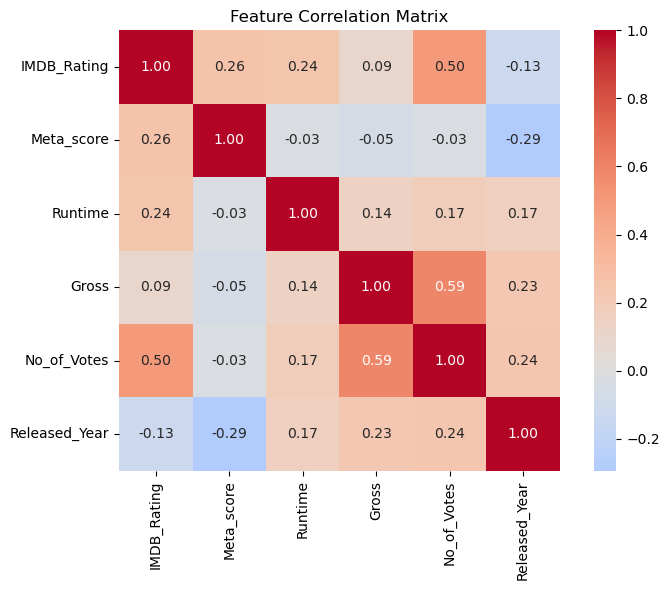

In [31]:
# We will plot the feature correlation matrix to see if there are any features that can be dropped
# besides the ones we will decide to remove based on irrelevance

numerical_cols = ['IMDB_Rating', 'Meta_score', 'Runtime', 'Gross', 'No_of_Votes', 'Released_Year']

corr_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Since none of the features score high correlations we will not drop any.

In [32]:
# We will check for any low variance features
print("Variance of numerical columns:")
for col in numerical_cols :
    print(f"{df_clean[col].var():,.2f}")

Variance of numerical columns:
0.08
129.36
789.75
10,284,191,540,092,308.00
107,280,254,669.75
542.75


We see that most columns do not have low variance apart from rating which is the result of working on a list of the best 1000 movies which should all be rated high.

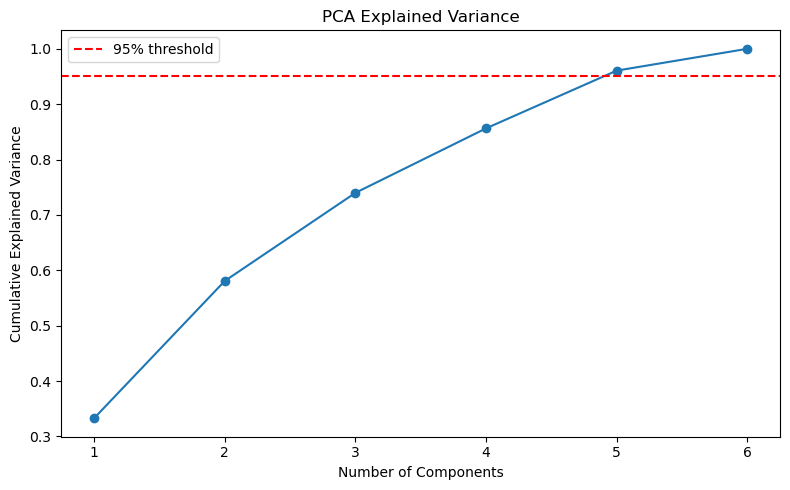

In [33]:
# Here we make a plot to see what is the maximum number of columns we can reduce to
# While maintaining at least 95 % of the data regarding the variance in our dataset

from sklearn.decomposition import PCA

scaled_cols = ['IMDB_Rating_Scaled', 'Meta_score_Scaled', 'Runtime_Scaled','Gross_Scaled', 'No_of_Votes_Scaled', 'Released_Year_Scaled']

pca = PCA()
pca.fit(df_clean[scaled_cols])

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
df_clean.shape

(999, 48)

From the plot we can see that we can reduce from the 6 dimensions to 5 as they are sufficient for 
capturing 95%+ of the total variance in the data, so we reduce the size while preserving accuracy.

In [35]:
# Here we do the principal component analysis as we have obsererved
# that the reduction can happen from 6 to 5 dimensions

pca = PCA(n_components=5)
pca_components = pca.fit_transform(df_clean[scaled_cols])

pca_df = pd.DataFrame(
    pca_components,
    columns=[f'PC{i+1}' for i in range(5)],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, pca_df], axis=1)

print(f"Shape after PCA: {df_clean.shape}")
print(f"\nPCA components sample:")
print(pca_df.head())

Shape after PCA: (999, 53)

PCA components sample:
        PC1       PC2       PC3       PC4       PC5
0  5.953119  3.117122 -0.136517 -3.309462  1.946853
1  5.021553  4.274224  0.564209 -1.050771  0.585877
2  8.314548  1.689929 -2.040206 -0.615414 -0.307024
3  3.771958  3.334641  2.073479 -1.038482  0.103528
4  1.207556  3.953538 -0.688978 -1.683969  1.170548


In [36]:
# We wil drop all the columns we no longer need
# They helped us transform and reduce our data
# Poster_link, overview were irrelevant from begining
# Genere and genre list are no longer needed
# And the scaled columns are no longer needed due to the pca

cols_to_drop = [
    'Poster_Link', 'Overview', 'Genre', 'Genre_List','IMDB_Rating_Scaled', 'Meta_score_Scaled', 'Runtime_Scaled',
'Gross_Scaled', 'No_of_Votes_Scaled', 'Released_Year_Scaled'
]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Shape after dropping: {df_clean.shape}")
print("\nRemaining columns:")
for col in df_clean.columns:
    print(f"  {col}")

Shape after dropping: (999, 43)

Remaining columns:
  Series_Title
  Released_Year
  Certificate
  Runtime
  IMDB_Rating
  Meta_score
  Director
  Star1
  Star2
  Star3
  Star4
  No_of_Votes
  Gross
  Genre_Action
  Genre_Adventure
  Genre_Animation
  Genre_Biography
  Genre_Comedy
  Genre_Crime
  Genre_Drama
  Genre_Family
  Genre_Fantasy
  Genre_Film-Noir
  Genre_History
  Genre_Horror
  Genre_Music
  Genre_Musical
  Genre_Mystery
  Genre_Romance
  Genre_Sci-Fi
  Genre_Sport
  Genre_Thriller
  Genre_War
  Genre_Western
  Cert_Adult
  Cert_UnderSupervision
  Cert_Universal
  Cert_Unknown
  PC1
  PC2
  PC3
  PC4
  PC5


Feature engineering

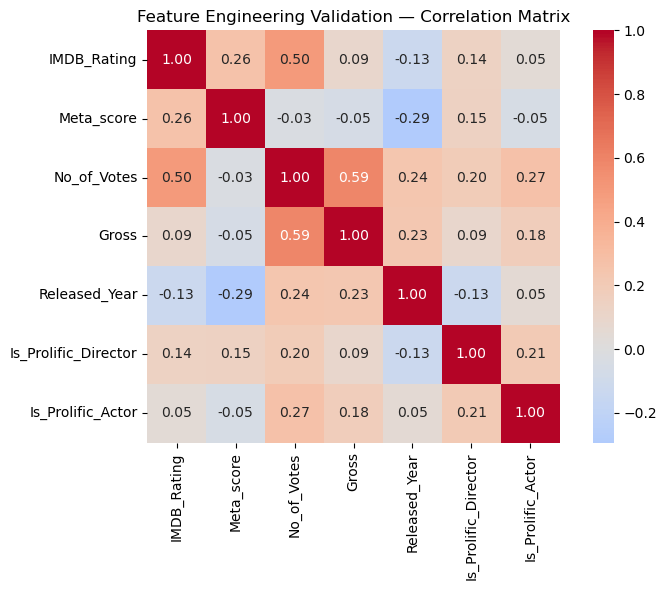

In [37]:
# We add 2 new features that should offer an interesting insight to the movies
# Is_Prolific_Director: 1 if director appears 3+ times
# Is_Prolific_Actor: 1 if any of the 4 stars appears 3+ times
# across all star columns combined

director_counts = df_clean['Director'].value_counts()
df_clean['Is_Prolific_Director'] = df_clean['Director'].map(
    lambda x: 1 if director_counts[x] >= 3 else 0
)

all_actors = pd.concat([
    df_clean['Star1'], df_clean['Star2'],df_clean['Star3'], df_clean['Star4']
])
actor_counts = all_actors.value_counts()

def has_prolific_actor(row):
    for col in ['Star1', 'Star2', 'Star3', 'Star4']:
        if actor_counts.get(row[col], 0) >= 3:
            return 1
    return 0

df_clean['Is_Prolific_Actor'] = df_clean.apply(has_prolific_actor, axis=1)

validation_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes','Gross', 'Released_Year','Is_Prolific_Director', 'Is_Prolific_Actor']

corr_matrix = df_clean[validation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Engineering Validation — Correlation Matrix')
plt.tight_layout()
plt.show()

Since none of the added column dont have high feature correlation with other columns we can assume that their addition offers different insight
to the dataset and they are far from redundant features.

**Part2 : Extracting& Visualizing Insights**

C:\Users\Mihai\AppData\Local\Temp\ipykernel_2092\4212417997.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='muted')


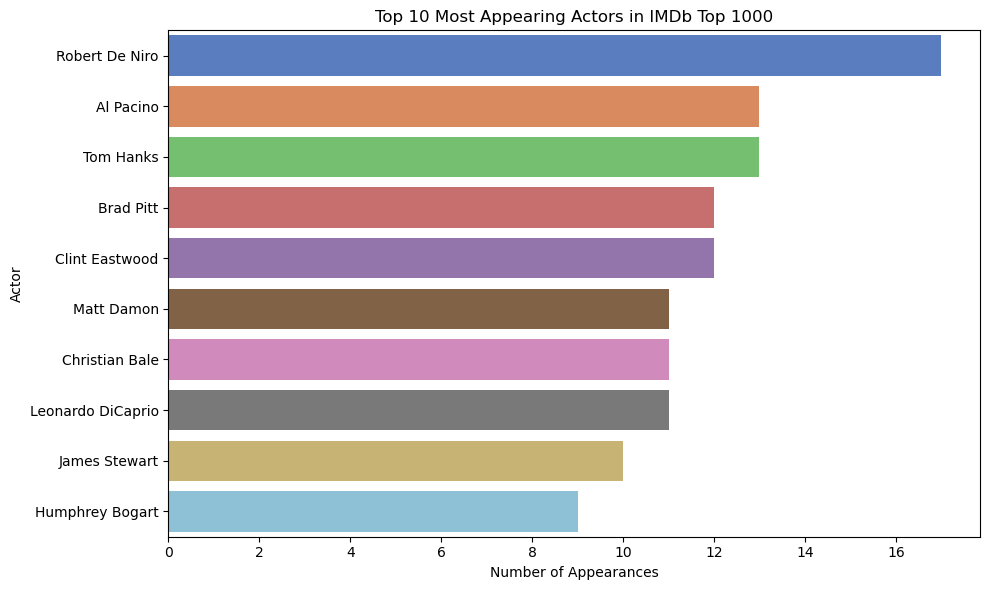

In [38]:
# How many times each actor appears
# I believe this is interesting because in a way is a statistical way of finding which actors
# really performed well
# As an insight either no younger actors had the time to act in more movies
# Or simply movies nowadays are worse therefore not making the top 1000
all_actors = pd.concat([
    df_clean['Star1'], df_clean['Star2'],df_clean['Star3'], df_clean['Star4']
])
top_actors = all_actors.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='muted')
plt.title('Top 10 Most Appearing Actors in IMDb Top 1000')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()

C:\Users\Mihai\AppData\Local\Temp\ipykernel_2092\3902199960.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=animal_series.values, y=animal_series.index, palette='muted')


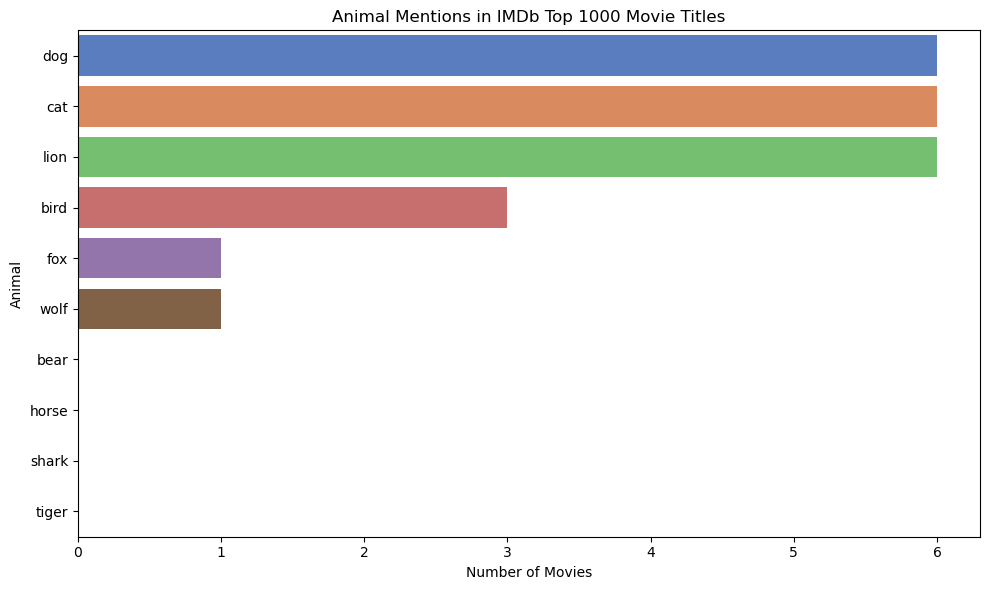

In [39]:
# What animals are most loved and easier to use as titles for great movies
# As a results we see that it is somehow as common to use dog cat and lion in a movie title
animals = ['dog', 'cat', 'lion', 'wolf', 'bear', 
           'fox', 'horse', 'shark', 'bird', 'tiger']

animal_counts = {}
for animal in animals:
    count = df_clean['Series_Title'].str.lower().str.contains(animal).sum()
    animal_counts[animal] = count

animal_series = pd.Series(animal_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=animal_series.values, y=animal_series.index, palette='muted')
plt.title('Animal Mentions in IMDb Top 1000 Movie Titles')
plt.xlabel('Number of Movies')
plt.ylabel('Animal')
plt.tight_layout()
plt.show()

C:\Users\Mihai\AppData\Local\Temp\ipykernel_2092\1780353689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='muted')


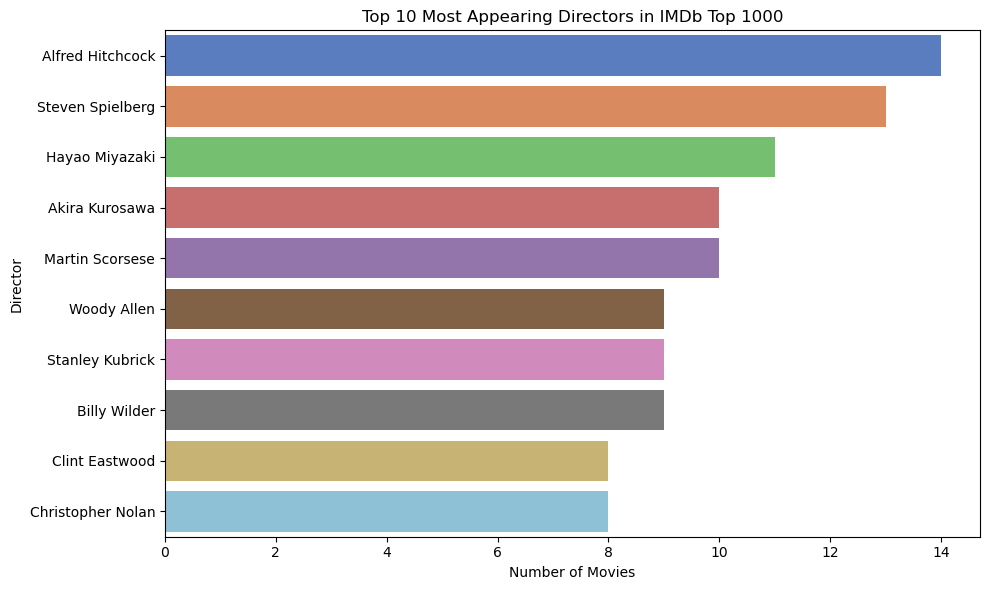

In [40]:
# The best directors by number of appearences
# I find this interesting because we see who can
# maintain a high level cotinously
# As a result the top 10 make out 10 % of the total movies 

top_directors = df_clean['Director'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='muted')
plt.title('Top 10 Most Appearing Directors in IMDb Top 1000')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

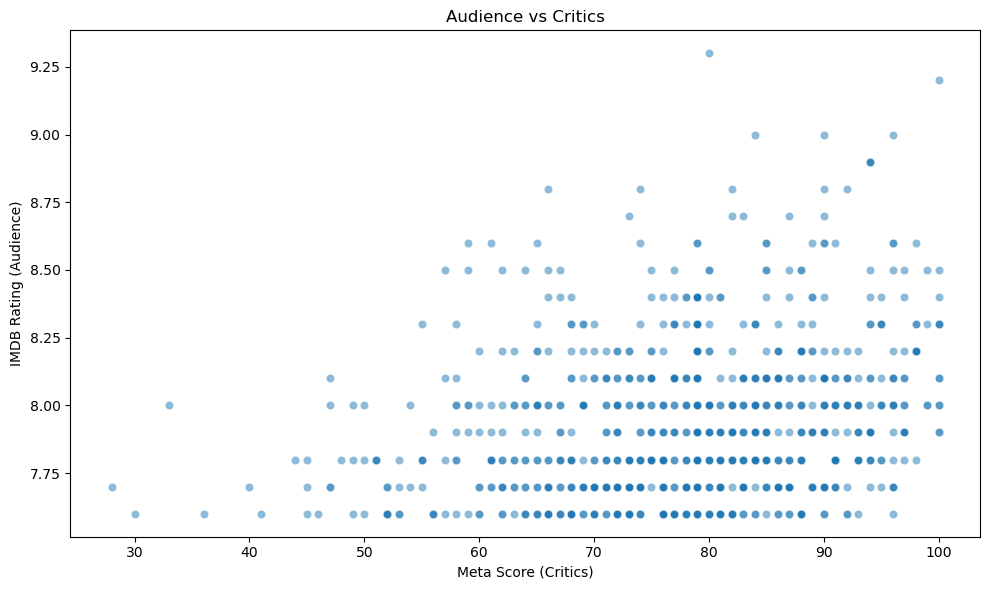

In [41]:
# Audience vs critics 
# We see how different movies are perceived by the public
#  and specialists
# We can see that there are almost no movies that are not appreciated by the public only
# Whereas there are a lot liked only by critics and not so much by the public(I mean they are still top 1000)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Meta_score', y='IMDB_Rating', alpha=0.5)
plt.title('Audience vs Critics')
plt.xlabel('Meta Score (Critics)')
plt.ylabel('IMDB Rating (Audience)')
plt.tight_layout()
plt.show()

C:\Users\Mihai\AppData\Local\Temp\ipykernel_2092\2010172666.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='muted')


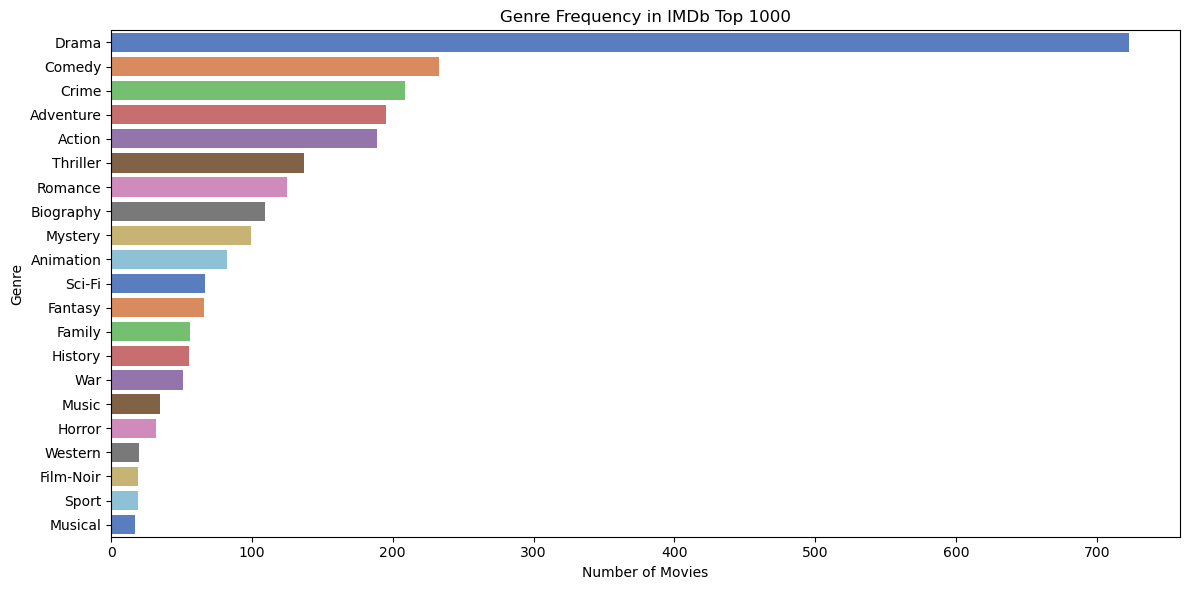

In [42]:
# Genre frequency : lets see which genres really stand out in the top 1000
# I find this interesting as humans tend to have a liking for 'drama'
# Making it a clear dominat genre for the great movie area

genre_counts = df_clean[[col for col in df_clean.columns 
                          if col.startswith('Genre_')]].sum().sort_values(ascending=False)
genre_counts.index = [col.replace('Genre_', '') for col in genre_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='muted')
plt.title('Genre Frequency in IMDb Top 1000')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

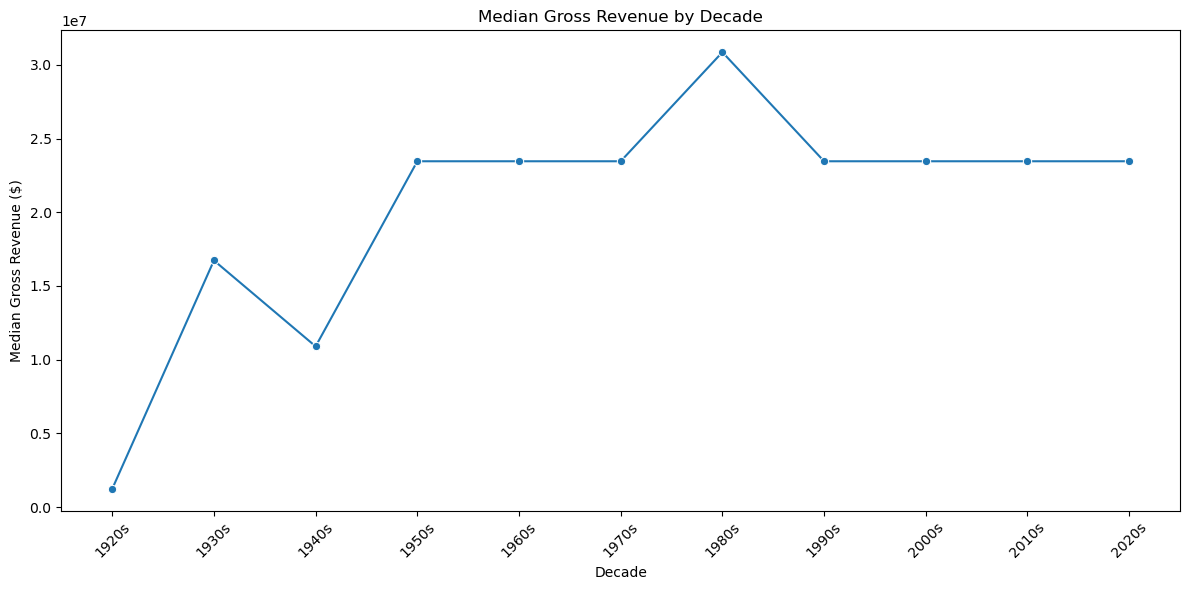

In [43]:
# Lets see which decades made the most money
# We can see that until the 90s we had a growth and then
# we hit stagnation does this affect all art or just movies ???
decade_gross = df_clean.groupby(
    df_clean['Released_Year'] // 10 * 10
)['Gross'].median().reset_index()
decade_gross.columns = ['Decade', 'Gross']
decade_gross['Decade'] = decade_gross['Decade'].astype(str) + 's'

plt.figure(figsize=(12, 6))
sns.lineplot(data=decade_gross, x='Decade', y='Gross', marker='o')
plt.title('Median Gross Revenue by Decade')
plt.xlabel('Decade')
plt.ylabel('Median Gross Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

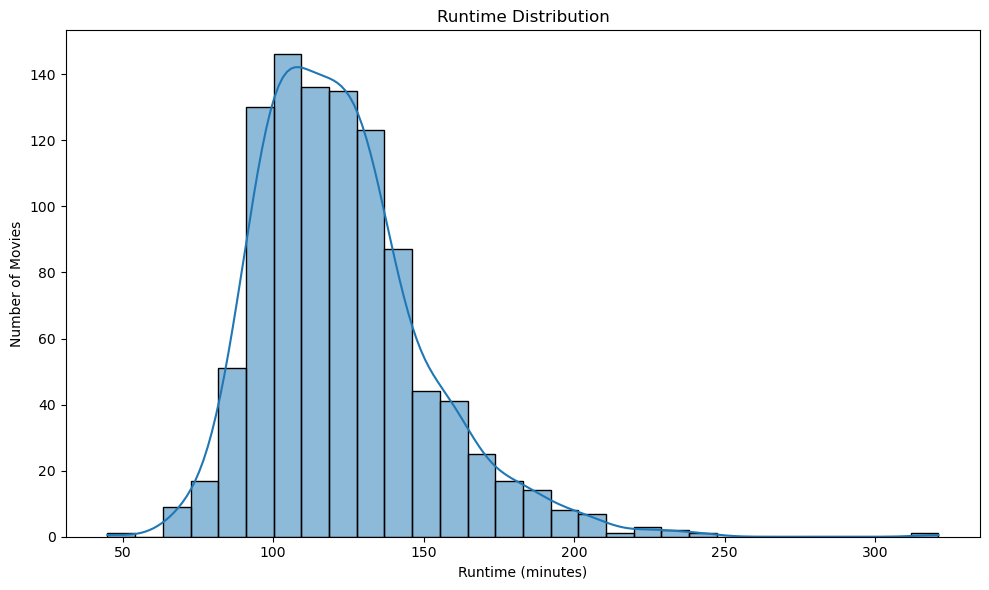

In [ ]:
# Runtime distribution should be interesting as it shows the industries 
# laws of accepting the range of 90-120 mins as industry standard 
# Seeing that extremes are rarer makes you think also if more means better in this case or not
# Same for less

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Runtime', bins=30, kde=True)
plt.title('Runtime Distribution')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

C:\Users\Mihai\AppData\Local\Temp\ipykernel_2092\2891934051.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cert_counts.values, y=cert_counts.index, palette='muted')


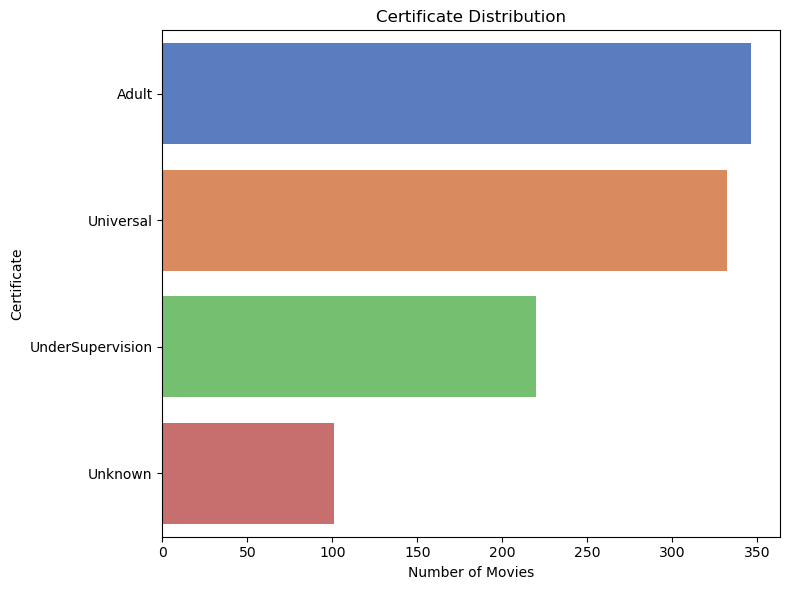

In [45]:
# Certificate distribution
# I find this interesting as seeing what is the general target audience
# It seems that most movies are made specifically for adults rather than for 
# everyone. Is that optimal for film producers considering budget ??

cert_counts = df_clean['Certificate'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=cert_counts.values, y=cert_counts.index, palette='muted')
plt.title('Certificate Distribution')
plt.xlabel('Number of Movies')
plt.ylabel('Certificate')
plt.tight_layout()
plt.show()

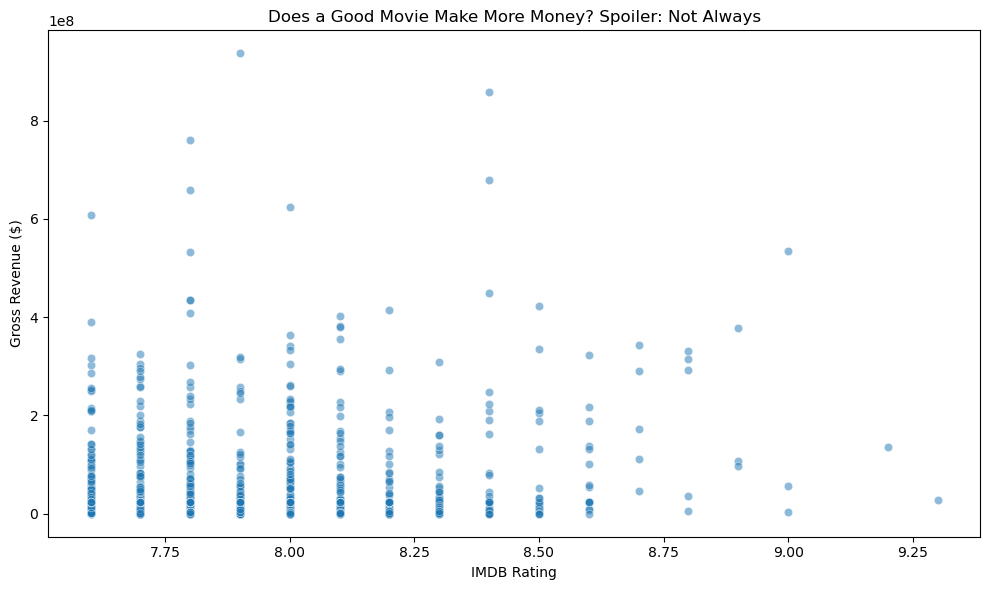

In [46]:
# Is gross income proportional to the rating
# I find this interesting because there is the possibility of outliers in 2 cases :
# a) Good movie small gross
# b) Worse movie big gross income
# What does really make a movie good ?
# As we can see the best movies dont make as much money as mid-lower tier ones

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='IMDB_Rating', y='Gross', alpha=0.5)
plt.title('Does a Good Movie Make More Money? Spoiler: Not Always')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue ($)')
plt.tight_layout()
plt.show()

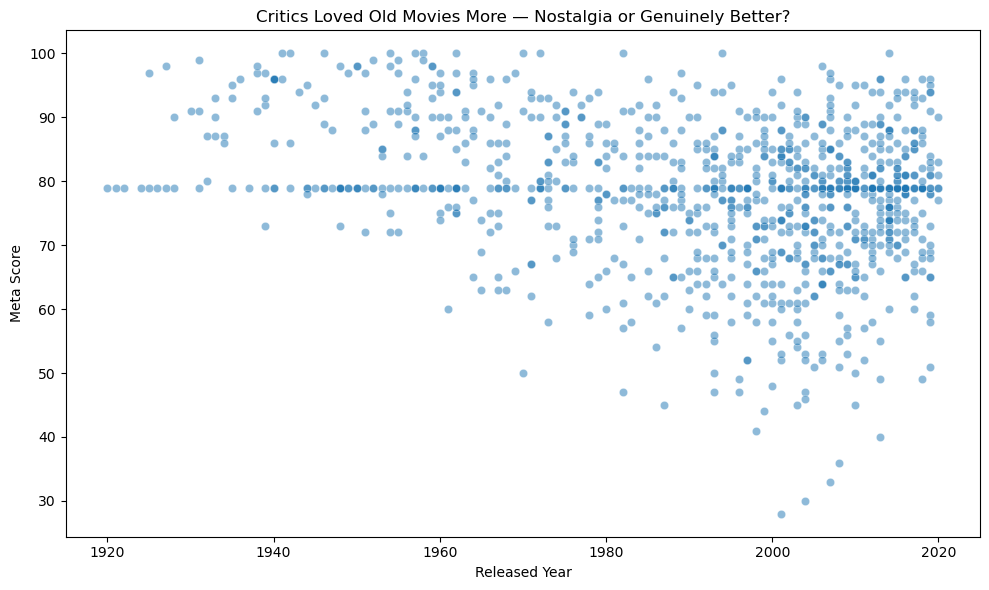

In [47]:
# Do critics love old movies or are they simply better
# I find this interesting as there is this unwritten law
# that movie critics preffer older movies
# As we can see from the chart the statement might actually be correct

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Released_Year', y='Meta_score', alpha=0.5)
plt.title('Critics Loved Old Movies More — Nostalgia or Genuinely Better?')
plt.xlabel('Released Year')
plt.ylabel('Meta Score')
plt.tight_layout()
plt.show()

**Part3: Movie recomandation System**

In [51]:
# For the similarity algorithm I decided to use cosine similarity for the columns we have created 
# with pca from the numerical original ones + also the one hot encoding we have done for Genre and 
# Certificate columns . We will sum this result with Jacaard similairity for the Director, Star1-4 categorical columns
# I have made the decision of keeping the later separate as one hot encodinf done for them as well would have really 
# affected the size of the dataset negatively (having estimated 500 + unique values for most of the columns above)
# Since both cosine similarity and Jacaard similarity results reflect that closer to 1 higher the similarity I have decided
# that the top 5 highest added similarities should make up for a great way of realising the similarity search process.

from sklearn.metrics.pairwise import cosine_similarity

feature_cols = (
    ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'] +
    [col for col in df_clean.columns if col.startswith('Genre_')] +
    [col for col in df_clean.columns if col.startswith('Cert_')] +
    ['Is_Prolific_Director', 'Is_Prolific_Actor']
)

feature_matrix = df_clean[feature_cols].values
cosine_matrix = cosine_similarity(feature_matrix)

def get_recommendations(title, df, cosine_matrix, top_n=5):
    matches = df[df['Series_Title'].str.lower() == title.lower()]
    
    if len(matches) == 0:
        print("No movie found.Try again")
        return
    
    idx = matches.index[0]
    pos = df.index.get_loc(idx)
    
    cosine_scores = cosine_matrix[pos]
    
    input_people = set([
        df.loc[idx, 'Director'], df.loc[idx, 'Star1'],df.loc[idx, 'Star2'], df.loc[idx, 'Star3'],df.loc[idx, 'Star4']
    ])
    
    results = []
    for i, row_idx in enumerate(df.index):
        if row_idx == idx:
            continue
        candidate_people = set([
            df.loc[row_idx, 'Director'], df.loc[row_idx, 'Star1'],
            df.loc[row_idx, 'Star2'], df.loc[row_idx, 'Star3'],
            df.loc[row_idx, 'Star4']
        ])
        jaccard = len(input_people & candidate_people) / len(input_people | candidate_people)
        final_score = cosine_scores[i] + jaccard
        results.append((row_idx, final_score))
    
    results = sorted(results, key=lambda x: x[1], reverse=True)[:top_n]
    
    recommendations = pd.DataFrame([{
        'Title': df.loc[r[0], 'Series_Title'],
        'IMDB_Rating': df.loc[r[0], 'IMDB_Rating'],
        'Director': df.loc[r[0], 'Director'],
        'Main actor' : df.loc[r[0], 'Star1'],
        'Score' : r[1]
    } for r in results])
    
    return recommendations

print(get_recommendations('Titanic', df_clean, cosine_matrix))

                                        Title  IMDB_Rating       Director  \
0                                      Avatar          7.8  James Cameron   
1                           Avengers: Endgame          8.4  Anthony Russo   
2  Star Wars: Episode VII - The Force Awakens          7.9    J.J. Abrams   
3                      Avengers: Infinity War          8.4  Anthony Russo   
4                                The Avengers          8.0    Joss Whedon   

          Main actor     Score  
0    Sam Worthington  1.045926  
1          Joe Russo  0.958322  
2       Daisy Ridley  0.902351  
3          Joe Russo  0.901775  
4  Robert Downey Jr.  0.889285  


In [48]:
df_clean.head(5)

,Series_Title,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,...,Cert_UnderSupervision,Cert_Universal,Cert_Unknown,PC1,PC2,PC3,PC4,PC5,Is_Prolific_Director,Is_Prolific_Actor
0,The Shawshank Redemption,1994,Adult,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,...,False,False,False,5.953119,3.117122,-0.136517,-3.309462,1.946853,0,1
1,The Godfather,1972,Adult,175,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,...,False,False,False,5.021553,4.274224,0.564209,-1.050771,0.585877,1,1
2,The Dark Knight,2008,UnderSupervision,152,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,...,True,False,False,8.314548,1.689929,-2.040206,-0.615414,-0.307024,1,1
3,The Godfather: Part II,1974,Adult,202,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,...,False,False,False,3.771958,3.334641,2.073479,-1.038482,0.103528,1,1
4,12 Angry Men,1957,Universal,96,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,...,False,True,False,1.207556,3.953538,-0.688978,-1.683969,1.170548,1,1
